In [1]:
from atomic_units import AtomicUnitSystem, hartree_atomic_base_units

# Példa: Hartree Atomic Unit System
hau_system = AtomicUnitSystem(base_units=hartree_atomic_base_units)
print(hau_system.length_unit)
print(hau_system.energy_unit)

5.2917721090397754e-11 meter
4.35974472220717e-18 joule


In [2]:
import atomic_units as au
import pint
import numpy as np

hb=1.0
e0=1.0
m0=100.0
kappa0=1.0 # 4*pi*epsilon0
dx=0.025

print(1.0/(2*dx**2))
alpha_times_c = e0**2/(kappa0*hb)
print(alpha_times_c)
#print(e0**2/(kappa0*hb))

prefactor = hb**2/(2*m0*dx**2)
desired_prefactor = 0.5
prefactor_error = np.abs(prefactor-desired_prefactor)/desired_prefactor
print(f"Prefactor: {prefactor}")
print(f"Prefactor error: {prefactor_error}")

ureg = pint.UnitRegistry()

length_unit = ((kappa0 * hb ** 2 / (m0 * e0 ** 2))*ureg.bohr).to('nm')
step_unit = dx*length_unit
desired_step_unit = 0.1*ureg.nm
step_unit_error = (np.abs(step_unit-desired_step_unit)/desired_step_unit).magnitude
print(f"step unit in SI: {step_unit.to('nm')}")
print(f"step unit error: {step_unit_error}")

scaled_units_system = au.AtomicUnitSystem(xh=hb, xe=e0, xm=m0, xk=kappa0)

print(scaled_units_system)
print(scaled_units_system.mass_unit.to('kg'))

print(f"Length unit: {scaled_units_system.length_unit.to('nm')}")
print(f"Step unit: {dx*scaled_units_system.length_unit.to('nm')}")
print(f"Length unit in AU: {scaled_units_system.length_unit.to('bohr')}")


799.9999999999999
1.0
Prefactor: 7.999999999999998
Prefactor error: 14.999999999999996
step unit in SI: 1.3229430272599437e-05 nanometer
step unit error: 0.999867705697274
Value of atomic base units in this rescaled atomic units:
- modified planck constant hbar := 1.0
- elementary charge := 1.0
- electron mass := 100.0
- modified permittivity := 1.0

Derived units in this rescaled atomic unit system:
- length unit := 	5.291772109039775e-09 meter
- energy unit := 	4.35974472220717e-20 joule
- time unit := 	2.4188843265856802e-15 second
- frequency unit := 	413413733351824.5 hertz
- velocity unit := 	2187691.2636451917 meter / second
- speed of light := 	137.03599908356242
- electric field unit := 	51422067.47623178 volt / meter
- electric potential unit := 	0.2721138624598847 volt

9.1093837015e-33 kilogram
Length unit: 5.2917721090397745 nanometer
Step unit: 0.13229430272599438 nanometer
Length unit in AU: 99.99999999999999 bohr


# testing masking functions

0.20202020202020243


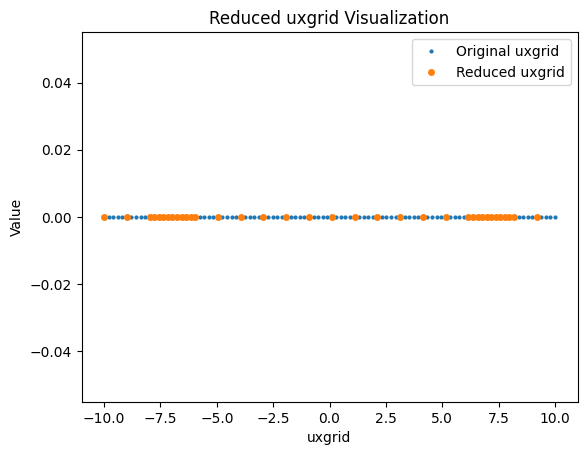

In [3]:
import numpy as np
import matplotlib.pyplot as plt

uxgrid_num = 100
uxgrid = np.linspace(-10, 10, uxgrid_num)
uxgrid_dx = uxgrid[1]-uxgrid[0]
print(uxgrid_dx)

# Desired number of points
desired_points = 20

# Calculate the step size to reduce the number of points
step_size = uxgrid_num // desired_points

# Create the mask
mask = np.zeros(uxgrid_num, dtype=bool)
mask[::step_size] = True

# Create the reduced uxgrid by taking every step_size-th point
reduced_uxgrid = uxgrid[mask]

# Highlighted ranges
highlight_ranges = [(-8, -6), (6, 8)]

# Initialize mask
mask_highlight_ranges = np.zeros(uxgrid_num, dtype=bool)

# Apply mask for highlighted ranges
for start, end in highlight_ranges:
    mask_highlight_ranges |= (uxgrid >= start) & (uxgrid <= end)

# Number of highlighted points
highlighted_num = np.sum(mask_highlight_ranges)

mask += mask_highlight_ranges

# Create the reduced uxgrid by taking every step_size-th point
reduced_uxgrid = uxgrid[mask]

# Plot
plt.plot(uxgrid, np.zeros_like(uxgrid), 'o', markersize=2, label='Original uxgrid')
plt.plot(reduced_uxgrid, np.zeros_like(reduced_uxgrid), 'o', markersize=4, label='Reduced uxgrid')
plt.xlabel('uxgrid')
plt.ylabel('Value')
plt.title('Reduced uxgrid Visualization')
plt.legend()
plt.show()

In [4]:
t_start=0
t_stop=12.0
utgrid_dt=0.1
utgrid=np.arange(t_start,t_stop,utgrid_dt)

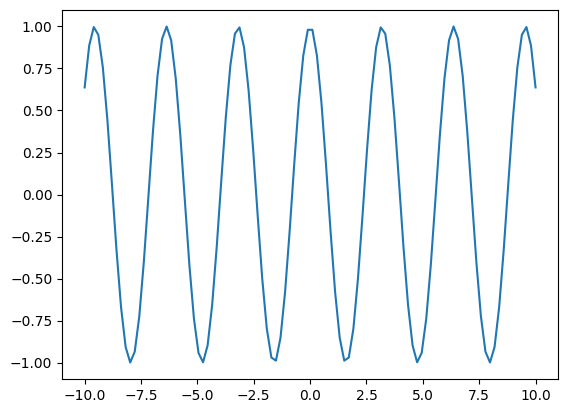

In [5]:
import quantum_toolkit as quat

k_pw = 2

dispersion=quat.Dispersion(uxgrid_dx)

wave_function = quat.plane_wave(dispersion.k2omega(k_pw), uxgrid)

plt.plot(uxgrid, np.real(wave_function['value']))


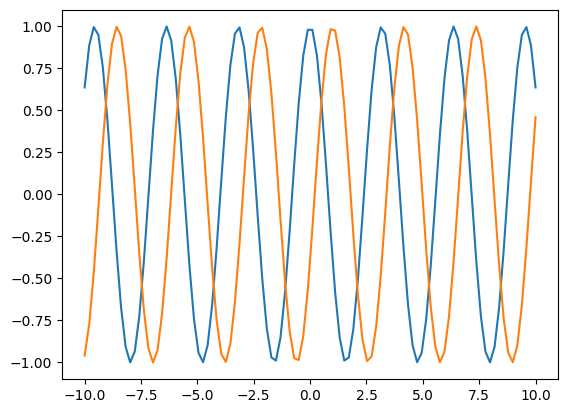

In [6]:
te_wave_function = quat.stationary_time_evolution(dispersion.k2omega(k_pw), utgrid, wave_function)

plt.plot(uxgrid, np.real(te_wave_function['value'][:,0]))
plt.plot(uxgrid, np.real(te_wave_function['value'][:,10])) 

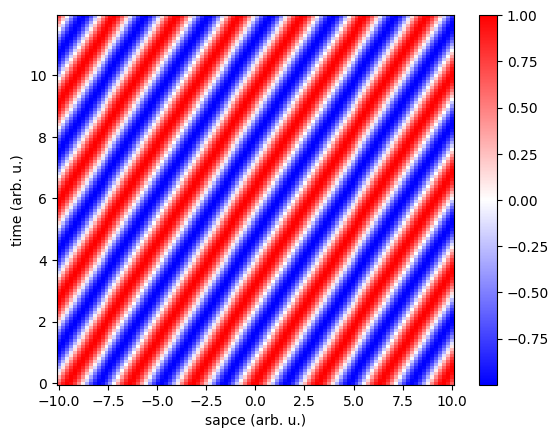

In [7]:
X,Y = np.meshgrid(uxgrid,utgrid)

Z=np.transpose(np.real(te_wave_function['value']))

#z_min, z_max = -np.abs(Z).max(), np.abs(Z).max()
    
pcm = plt.pcolormesh(X,Y,Z,cmap ='bwr') #plt.pcolormesh(X, Y, Z, cmap ='bwr', vmin = z_min, vmax = z_max)
plt.colorbar(pcm)
 
#plt.title('Prob. dens. width external field', fontweight ="bold")
plt.xlabel("sapce (arb. u.)")
plt.ylabel("time (arb. u.)")
#plt.xlim([-0.8*modelpot.wellwidth, 0.8*modelpot.wellwidth])
#plt.ylim(0,2*laserpot_cep0.temporal_width)
plt.show()

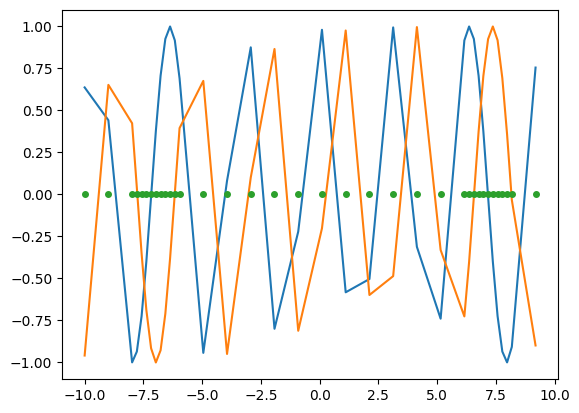

In [8]:
reduced_te_wave_function = quat.stationary_time_evolution(dispersion.k2omega(k_pw), utgrid, wave_function, mask)

plt.plot(reduced_uxgrid, np.real(reduced_te_wave_function['value'][:,0]))
plt.plot(reduced_uxgrid, np.real(reduced_te_wave_function['value'][:,10])) 
plt.plot(reduced_uxgrid, np.zeros_like(reduced_uxgrid), 'o', markersize=4, label='Reduced uxgrid')
plt.show()

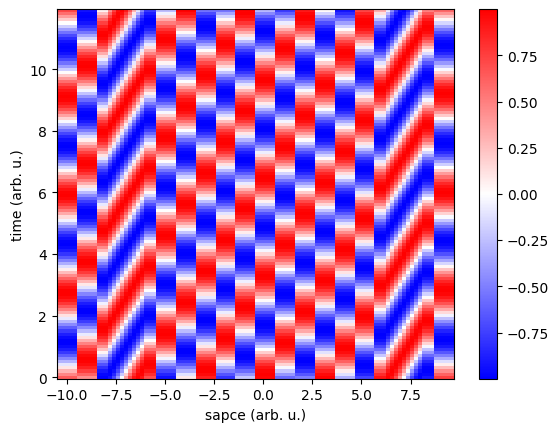

In [9]:
X,Y = np.meshgrid(reduced_uxgrid,utgrid)

Z=np.transpose(np.real(reduced_te_wave_function['value']))
    
pcm = plt.pcolormesh(X,Y,Z,cmap ='bwr') 
plt.colorbar(pcm)
 
plt.xlabel("sapce (arb. u.)")
plt.ylabel("time (arb. u.)")
plt.show()

# Set Atomic unit system

In [10]:
dx=0.025 # Grid step size in the unit system
emax=5 # Maximum electron energy in eV
npx = 16*1024

## Optimazitation
Dispersion relation on 1D discrete grid:
\begin{align}
c_t &= \frac{\hbar^2}{2 \, m_e \, dx}\\
E_{e} &= 2 \, c_t \, (1-\cos(k_e \, dx))
\end{align}
The connection between the wavenumber of the electron ($\lambda_e$) and the wavelength reads:
\begin{align}
k_e &= \frac{2 \pi}{\lambda_e} 
\end{align}
Lets note the number of the points under one $\lambda_e$ with $n_l$ thus $\lambda_e=n_l*dx$.
\begin{align}
E_{e} &= 2 \, c_t \, \left(1-\cos\left(\frac{2 \pi}{n_l}\right)\right)\\
c_t &= \frac{E_{e}}{2 \, \left(1-\cos\left(\frac{2 \pi}{n_l}\right)\right)}
\end{align}

In [11]:
import math

desired_points_in_lamda = 20 # Desired number of points in the one lambda
desired_ct=emax/(2*(1-math.cos(2*np.pi/desired_points_in_lamda)))
print(desired_ct)

51.07932273632671


In [12]:
desired_width = 1600 # width in nm

In [13]:
from scipy.optimize import minimize
import atomic_units as au
from atomic_units import hartree_atomic_unit_system as haus

#print(emax*haus.ureg("eV"),haus.energy_unit.to("eV"))

def objective_function(x):

    #xhb=1
    #xe=1
    hb, m0, k0, xe = x
    usys = au.AtomicUnitSystem(xh=hb, xe=xe, xm=m0, xk=k0)

    #emax_in_usys = (emax*usys.ureg("eV")/usys.energy_unit.to("eV")).magnitude
    desired_width_in_nm = desired_width*usys.ureg("nm")
    width_in_nm = npx*dx*usys.length_unit.to("nm")
    delta_width = (abs(width_in_nm-desired_width_in_nm)/desired_width_in_nm).magnitude

    # Calculate the prefactor
    ct=quat.const_t(dx,hb,m0)

    delta_ct=(desired_ct-ct)/desired_ct#abs(ct-desired_ct)/desired_ct
    #delta_ct=0 if ct < desired_ct else abs(ct-desired_ct)/desired_ct

    #delta_e=abs(emax_in_usys-2*ct)
    #delta_length=abs((dx*usys.length_unit.to("nm")-0.1*usys.ureg("nm")).magnitude)
    #print(m0,k0,emax_in_usys,usys.energy_unit.to("eV"),delta_e)
    print("act.:",delta_width, delta_ct)

    return delta_ct**2 + delta_width**2

result = minimize(objective_function, [1,1,1,1], bounds=((1, 10000),(1,10000),(1,1000), (1,1000) ), method='L-BFGS-B')
print(result.x)  # Optimal solution
print(result.fun)  # Objective function value at the optimal solution

act.: 0.9864530634008583 -14.661914785550866
act.: 0.9864530636717969 -14.66191509878916
act.: 0.9864530632653888 -14.66191462893172
act.: 0.9864530635363274 -14.661914785550866
act.: 0.9864530631299195 -14.661914785550866
act.: 5.920044458384678 0.9659741093061623
act.: 5.920044319983791 0.9659741086256446
act.: 5.920044458535017 0.9659741093069015
act.: 5.920044389184235 0.9659741093061623
act.: 5.920044589762682 0.9659741093061623
act.: 1.163548048842333 0.8984063655872724
act.: 1.1635480055713734 0.8984063635553998
act.: 1.1635480489826762 0.8984063655938626
act.: 1.1635480272068537 0.8984063655872724
act.: 1.1635480913554557 0.8984063655872724
act.: 0.43787117789054636 0.7161490581020215
act.: 0.4378711845869019 0.7161490547206493
act.: 0.4378711778544033 0.7161490581202723
act.: 0.4378711821179732 0.7161490581020215
act.: 0.43787116664797004 0.7161490581020215
act.: 0.41279524401459206 0.7127951910996579
act.: 0.41279525096826647 0.7127951876985807
act.: 0.4127952439768412 0.7127

In [14]:
from scipy.optimize import minimize
import atomic_units as au
from atomic_units import hartree_atomic_unit_system as haus

#print(emax*haus.ureg("eV"),haus.energy_unit.to("eV"))

def objective_function(x):

    #xhb=1
    #xe=1
    hb = 3.2
    k0 = 1.2
    m0, xe = x
    usys = au.AtomicUnitSystem(xh=hb, xe=xe, xm=m0, xk=k0)

    #emax_in_usys = (emax*usys.ureg("eV")/usys.energy_unit.to("eV")).magnitude
    desired_width_in_nm = desired_width*usys.ureg("nm")
    width_in_nm = npx*dx*usys.length_unit.to("nm")
    delta_width = (abs(width_in_nm-desired_width_in_nm)/desired_width_in_nm).magnitude

    # Calculate the prefactor
    ct=quat.const_t(dx,hb,m0)

    delta_ct=delta_ct=(desired_ct-ct)/desired_ct#abs(ct-desired_ct)/desired_ct
    #delta_ct=0 if ct < desired_ct else abs(ct-desired_ct)/desired_ct

    #delta_e=abs(emax_in_usys-2*ct)
    #delta_length=abs((dx*usys.length_unit.to("nm")-0.1*usys.ureg("nm")).magnitude)
    #print(m0,k0,emax_in_usys,usys.energy_unit.to("eV"),delta_e)
    print("act.:",delta_width, delta_ct)

    return delta_ct**2 + delta_width**2

result = minimize(objective_function, [158,2], bounds=((1, 1000),(1,1000) ), method='L-BFGS-B')
print(result.x)  # Optimal solution
print(result.fun)  # Objective function value at the optimal solution

act.: 0.30325000564309634 -0.015050679772410785
act.: 0.3032500055989982 -0.015050679708167022
act.: 0.30324999867559627 -0.015050679772410785
act.: 0.022305555819952475 -0.015032255423699396
act.: 0.022305555884654354 -0.015032255359457998
act.: 0.02230556425976488 -0.015032255423699396
act.: 0.006663924275612203 -0.015032895974806483
act.: 0.00666392421274395 -0.015032895910564946
act.: 0.006663915956243045 -0.015032895974806483
act.: 0.00010973701846111794 -0.015031874472248323
act.: 0.00010973695517805027 -0.015031874408006785
act.: 0.00010972867168661082 -0.015031874472248323
act.: 2.9011738202200377e-06 -0.015030961842465274
act.: 2.9012371105352486e-06 -0.015030961778224014
act.: 2.90952106865916e-06 -0.015030961842465274
act.: 0.00012176724321420807 -0.015028154373154304
act.: 0.00012176730651177081 -0.015028154308913463
act.: 0.00012177559097025891 -0.015028154373154304
act.: 0.00035468352332699736 -0.015017192252253527
act.: 0.00035468358663848676 -0.015017192188014077
act.: 

In [15]:
import atomic_units as au

hb=3.2
e0=2.4
m0=160.0
kappa0=1.2 # 4*pi*epsilon0
dx=0.025

unit_sys = au.AtomicUnitSystem(xh=hb, xe=e0, xm=m0, xk=kappa0)

#print(unit_sys)
print(unit_sys.fine_structure_constant)
print(unit_sys.energy_unit.to('eV'))
print(unit_sys.length_unit.to('nm'))
print(dx*unit_sys.length_unit.to('nm'))

0.007297352569307099 dimensionless
0.07558718401663465 electron_volt
3.9688290817798304 nanometer
0.09922072704449576 nanometer


# Set unified grid

In [16]:
import numpy as np

uxgrid_num = 16*1024
uxgrid_dx = dx
uxgrid_width=uxgrid_num*uxgrid_dx
uxgrid = np.arange( -uxgrid_width/2 , uxgrid_width/2, uxgrid_dx)

print(type(uxgrid)) 
print(uxgrid_dx)
print(uxgrid_width)
print(uxgrid_width*unit_sys.length_unit.to('nm'))

<class 'numpy.ndarray'>
0.025
409.6
1625.6323918970186 nanometer


In [17]:
import quantum_toolkit as quat
# Create a dispersion object with the specified grid spacing
dispersion=quat.Dispersion(uxgrid_dx, hbar = unit_sys.hb,\
                            mass = unit_sys.me)

2.4178695952691127
41
[-48.35739191 -45.93952231 -43.52165271 -41.10378312 -38.68591352
 -36.26804393 -33.85017433 -31.43230474 -29.01443514 -26.59656555
 -24.17869595 -21.76082636 -19.34295676 -16.92508717 -14.50721757
 -12.08934798  -9.67147838  -7.25360879  -4.83573919  -2.4178696
   0.           2.4178696    4.83573919   7.25360879   9.67147838
  12.08934798  14.50721757  16.92508717  19.34295676  21.76082636
  24.17869595  26.59656555  29.01443514  31.43230474  33.85017433
  36.26804393  38.68591352  41.10378312  43.52165271  45.93952231
  48.35739191]


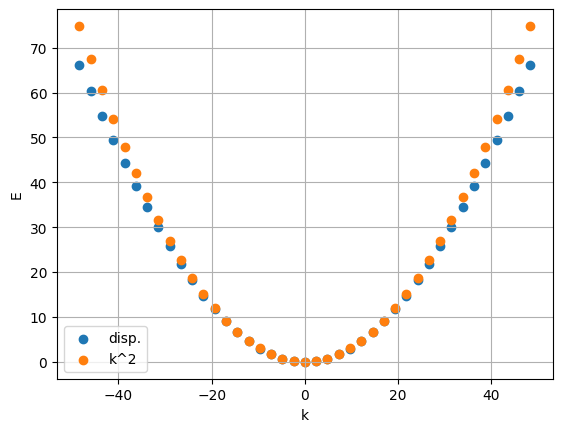

In [18]:
emax_in_unit_sys = emax*unit_sys.convert_energy_from("eV")
k_max = dispersion.energy2k(1.0*emax_in_unit_sys)

ukgrid_max = k_max
ukgrid_min = -k_max
ukgrid_num = 41

ukgrid, ukgrid_dx = np.linspace(ukgrid_min, ukgrid_max,\
                               ukgrid_num,retstep=True)

print(ukgrid_dx)
print(ukgrid_num)
print(ukgrid)

plt.scatter(ukgrid,dispersion.k2energy(ukgrid),label="disp.")
plt.scatter(ukgrid,((unit_sys.hb**2)/(2*unit_sys.me))*ukgrid**2,label="k^2")
plt.xlabel("k")
plt.ylabel("E")
plt.legend()
plt.grid()
plt.show()

In [19]:


print(k_max)
lambda_min = 2*np.pi/k_max
print(lambda_min)
num_of_points_in_lambda = 2*lambda_min/uxgrid_dx
print(num_of_points_in_lambda)

48.35739190538226
0.12993226184475548
10.394580947580438


#Paraméter szett csak az elejére

potenciál magassága max pár eV GaN és arany vagy amit a Vaclav használt
geometriát is kb realisztikusra
potenciál gát magassága legyen 1 vagy 2 eV

Ha ez nem mutat semmit akkor periódikussat
a szélessége egy oxid réteg széles 




# Set model-potential

In [20]:

print((10 * unit_sys.ureg("bohr").to("m") / unit_sys.length_unit).magnitude)
print(unit_sys.length_unit)

0.13333333333333336
3.968829081779831e-09 meter


-3.49 electron_volt 0.07558718401663465 electron_volt
-46.171848381492126
0.9600000000000001 electron_volt 0.07558718401663465 electron_volt
12.700565743906143
0.07558718401663465
0.13333333333333336
201.5707866263765


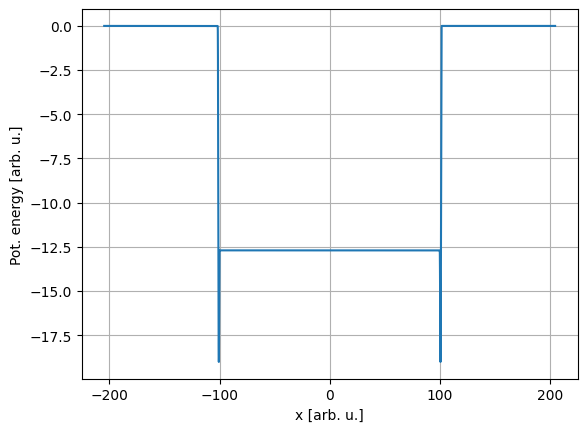

In [21]:
import matplotlib.pyplot as plt
import potentials as pots
import pint

ureg = unit_sys.ureg

#Standard electrode lists
#https://chem.libretexts.org/Ancillary_Materials/Reference/Reference_Tables/Electrochemistry_Tables/P1%3A_Standard_Reduction_Potentials_by_Element
#https://www.engineeringtoolbox.com/electrode-potential-d_482.html
#https://en.wikipedia.org/wiki/Standard_electrode_potential_(data_page)
#https://nano3dsystems.com/wp-content/uploads/2019/06/Ir.pdf
standard_potential_of_Au_in_V=1.83*ureg.volt #http://hyperphysics.phy-astr.gsu.edu/hbase/Tables/electpot.html
standard_potential_of_Al_in_V=-1.66*ureg.volt 
standard_potential_of_Ir_in_V=0.87*ureg.volt #standard_potential_of_Ir_in_V=0.87 #10.1002/elan.200403200
standard_potential_of_O3_in_V=1.246*ureg.volt # standard_potential_of_O3_in_V=1.246 #https://www.chm.uri.edu/weuler/chm112/refmater/redpottable.html

wall_in_V = standard_potential_of_Al_in_V-standard_potential_of_Au_in_V
wall_in_eV = (wall_in_V*ureg("elementary_charge").to("C")).to("eV")
wall_in_unit_sys = (wall_in_eV/unit_sys.energy_unit.to("eV")).magnitude
print(wall_in_eV,unit_sys.energy_unit.to("eV"))
print(wall_in_unit_sys)

well_in_V = standard_potential_of_Au_in_V-standard_potential_of_Ir_in_V
well_in_eV = (well_in_V*ureg("elementary_charge").to("C")).to("eV")
well_in_unit_sys = (well_in_eV/unit_sys.energy_unit.to("eV")).magnitude
print(well_in_eV,unit_sys.energy_unit.to("eV"))
print(well_in_unit_sys)

energy_unit_in_ev = unit_sys.energy_unit.to('eV').magnitude
print(energy_unit_in_ev)
length_unit_in_nm = unit_sys.length_unit.to('nm').magnitude


wall_width = (10 * unit_sys.ureg("bohr").to("m") / unit_sys.length_unit).magnitude
print(wall_width)
well_width = 800/length_unit_in_nm
print(well_width)

modelpot=pots.SmoothStackPotential(uxgrid,wallwidth=wall_width,\
                                   wallheight=wall_in_unit_sys,\
                                   welldepth=well_in_unit_sys,\
                                   wellwidth=well_width,\
                                   wallrise = 2,\
                                   wellfall = 2)
#modelpot=StackPotential(uxgrid)

plt.plot(uxgrid,modelpot(0))
plt.xlabel("x [arb. u.]")
plt.ylabel("Pot. energy [arb. u.]")
#plt.xlim([-0.8*modelpot.wellwidth, 0.8*modelpot.wellwidth])
plt.grid()
plt.show()

/usr/local/lib/python3.10/dist-packages/matplotlib/cbook.py:1345: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  return np.asarray(x, float)


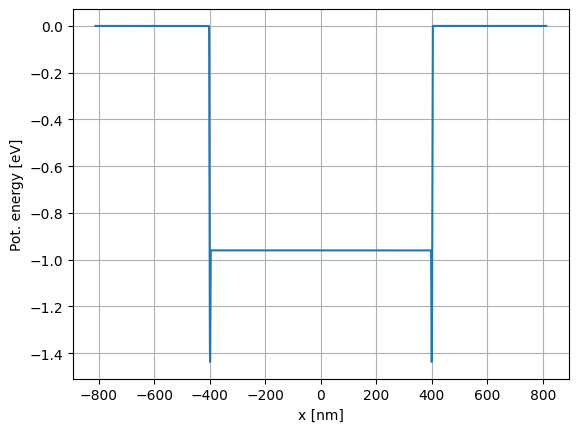

In [22]:
x = uxgrid * unit_sys.length_unit.to('nm')
y = modelpot(0) * unit_sys.energy_unit.to('eV')

plt.plot(x, y)
plt.xlabel("x [nm]")
plt.ylabel("Pot. energy [eV]")
#plt.xlim([-0.8*modelpot.wellwidth, 0.8*modelpot.wellwidth])
plt.grid()
plt.show()

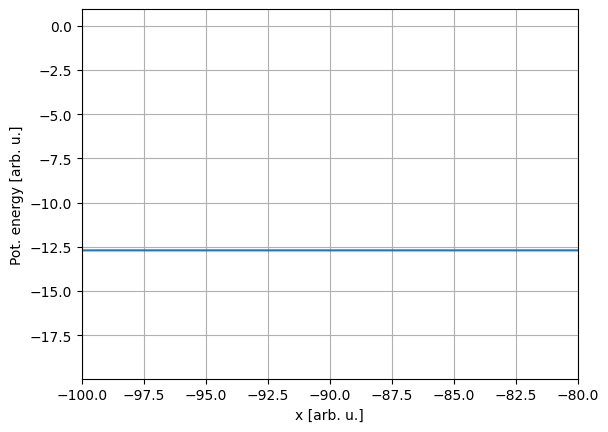

In [23]:
plt.plot(uxgrid,modelpot(0))
plt.xlabel("x [arb. u.]")
plt.ylabel("Pot. energy [arb. u.]")
plt.xlim([-100, -80])
plt.grid()
plt.show()

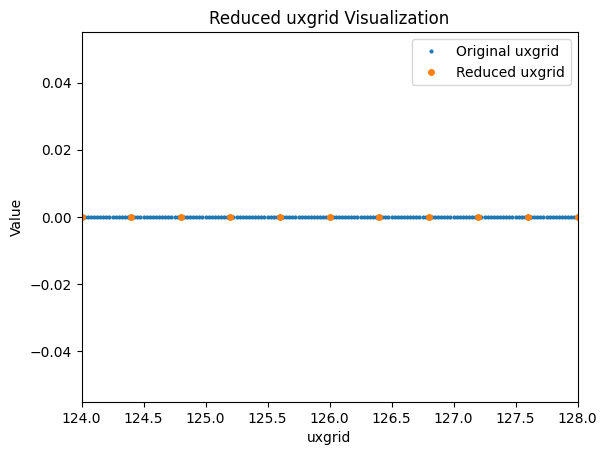

Original uxgrid length: 16384
Reduced uxgrid length: 1024


In [24]:
# Desired number of points
desired_points = 1024

# Calculate the step size to reduce the number of points
step_size = uxgrid_num // desired_points

# Create the mask
mask = np.zeros(uxgrid_num, dtype=bool)
mask[::step_size] = True

# Create the reduced uxgrid by taking every step_size-th point
reduced_uxgrid = uxgrid[mask]

# Plot
plt.plot(uxgrid, np.zeros_like(uxgrid), 'o', markersize=2, label='Original uxgrid')
plt.plot(reduced_uxgrid, np.zeros_like(reduced_uxgrid), 'o', markersize=4, label='Reduced uxgrid')
plt.xlim([124, 128])
plt.xlabel('uxgrid')
plt.ylabel('Value')
plt.title('Reduced uxgrid Visualization')
plt.legend()
plt.show()

print("Original uxgrid length:", len(uxgrid))
print("Reduced uxgrid length:", len(reduced_uxgrid))

In [25]:
# Highlighted ranges
highlight_ranges = [(-122, -118), (118, 122)]

# Initialize mask
mask_highlight_ranges = np.zeros(uxgrid_num, dtype=bool)

# Apply mask for highlighted ranges
for start, end in highlight_ranges:
    mask_highlight_ranges |= (uxgrid >= start) & (uxgrid <= end)

# Number of highlighted points
highlighted_num = np.sum(mask_highlight_ranges)

print(f"Number of uxgrid points: {uxgrid_num}")
print(f"Number of highlighted points: {highlighted_num}")

Number of uxgrid points: 16384
Number of highlighted points: 320


In [26]:
mask += mask_highlight_ranges

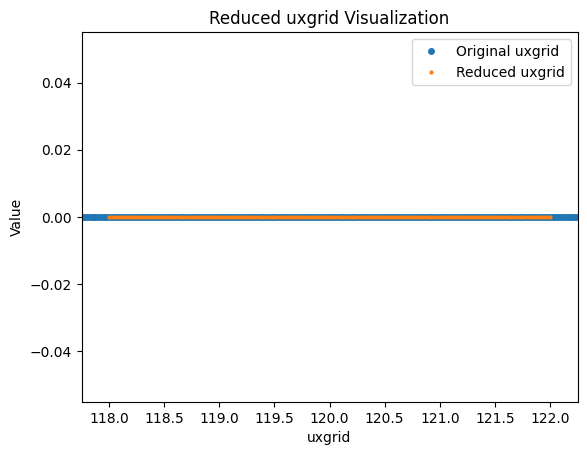

Original uxgrid length: 16384
Reduced uxgrid length: 1324


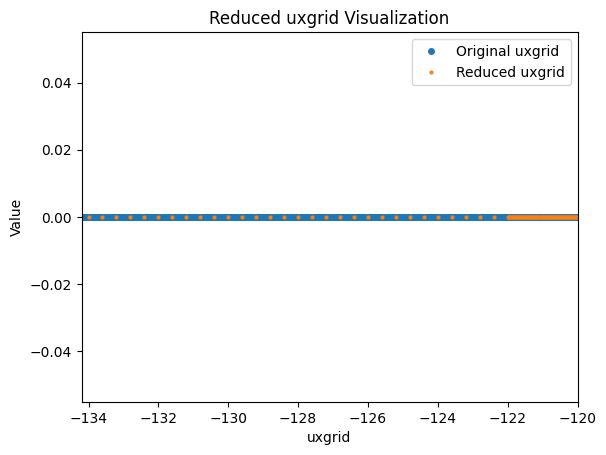

Original uxgrid length: 16384
Reduced uxgrid length: 1324


In [27]:
# Create the reduced uxgrid by taking every step_size-th point
reduced_uxgrid = uxgrid[mask]

# Plot
plt.plot(uxgrid, np.zeros_like(uxgrid), 'o', markersize=4, label='Original uxgrid')
plt.plot(reduced_uxgrid, np.zeros_like(reduced_uxgrid), 'o', markersize=2, label='Reduced uxgrid')
plt.xlim([highlight_ranges[1][0]-10*uxgrid_dx, highlight_ranges[1][1]+10*uxgrid_dx])
plt.xlabel('uxgrid')
plt.ylabel('Value')
plt.title('Reduced uxgrid Visualization')
plt.legend()
plt.show()

print("Original uxgrid length:", len(uxgrid))
print("Reduced uxgrid length:", len(reduced_uxgrid))

# Plot
plt.plot(uxgrid, np.zeros_like(uxgrid), 'o', markersize=4, label='Original uxgrid')
plt.plot(reduced_uxgrid, np.zeros_like(reduced_uxgrid), 'o', markersize=2, label='Reduced uxgrid')
plt.xlim([1.1*highlight_ranges[0][0], highlight_ranges[0][0]+2])
plt.xlabel('uxgrid')
plt.ylabel('Value')
plt.title('Reduced uxgrid Visualization')
plt.legend()
plt.show()

print("Original uxgrid length:", len(uxgrid))
print("Reduced uxgrid length:", len(reduced_uxgrid))

# Compute eigen states

In [28]:
#zeropot=quat.ZeroPotential(uxgrid)
zeropot=pots.ZeroPotential(uxgrid)
constpot=pots.ConstantPotential(uxgrid, 1.0)

ham_static = quat.HamiltonOperator(uxgrid,hbar=unit_sys.hb,\
                                   me=unit_sys.me,\
                                   charge=unit_sys.e0,\
                                   scalarpot=modelpot, vectorpot=zeropot )

In [29]:
import scipy.sparse as sparse

mat=ham_static(0)
eigenvalues, eigenvectors = sparse.linalg.eigsh(mat, 40,which = 'SR')

print(eigenvalues[0])

-17.949054318969335


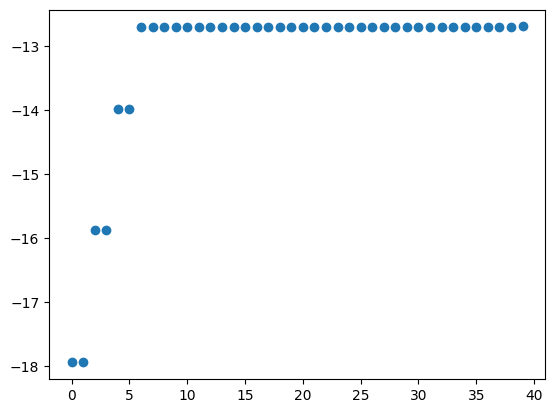

In [30]:
plt.scatter(np.arange(40),eigenvalues)

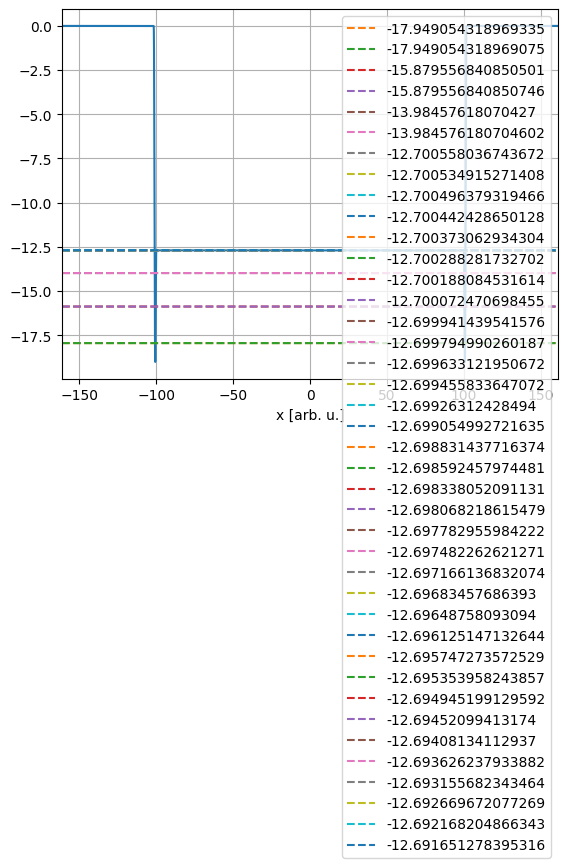

In [31]:
# plt.plot(uxgrid,modelpot(0),label="Pot")
# plt.plot(uxgrid,np.real(eigenvectors[:,0]),label="Re")
# plt.plot(uxgrid,np.imag(eigenvectors[:,0]),label="Im")
# plt.plot(uxgrid,np.abs(eigenvectors[:,0]),label="Abs")

plt.plot(uxgrid,modelpot(0))
for eval,evec  in zip(eigenvalues,np.transpose(eigenvectors)):
    plt.plot(uxgrid,eval*np.ones_like(uxgrid),"--",label=str(eval))
    #plt.plot(uxgrid,0.5*np.real(evec)+eval)#,label="Re")
    #plt.plot(uxgrid,0.5*np.imag(evec)+eval)#,label="Im")
    #plt.plot(uxgrid,np.abs(evec)**2+eval)#,label="Abs")
plt.xlabel("x [arb. u.]")
plt.xlim([-0.8*modelpot.wellwidth, 0.8*modelpot.wellwidth])
plt.legend(loc='upper right')
plt.grid()
plt.show()

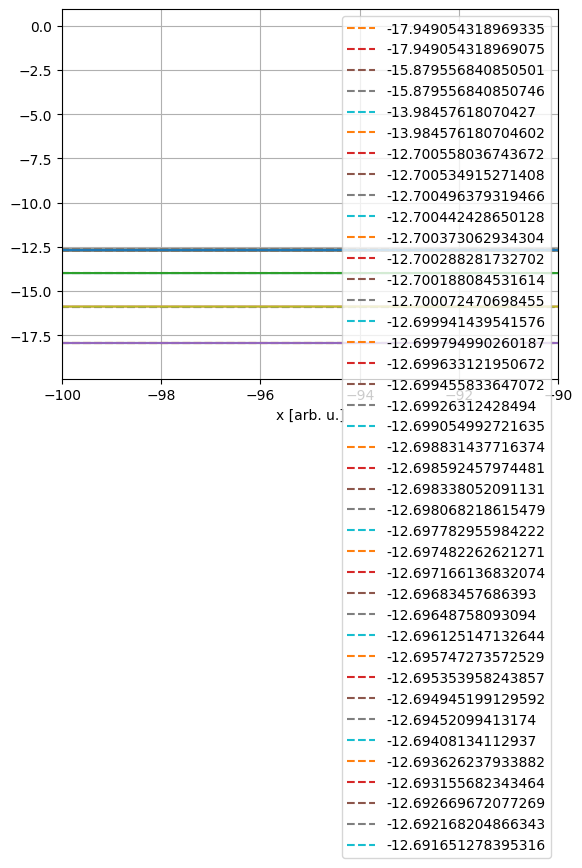

In [32]:
plt.plot(uxgrid,modelpot(0))
for eval,evec  in zip(eigenvalues,np.transpose(eigenvectors)):
    plt.plot(uxgrid,eval*np.ones_like(uxgrid),"--",label=str(eval))
    #plt.plot(uxgrid,0.5*np.real(evec)+eval)#,label="Re")
    #plt.plot(uxgrid,0.5*np.imag(evec)+eval)#,label="Im")
    plt.plot(uxgrid,np.abs(evec)**2+eval)#,label="Abs")
plt.xlabel("x [arb. u.]")
plt.xlim([-0.8*modelpot.wellwidth, 0.8*modelpot.wellwidth])
#plt.ylim(-520000,-480000)
plt.xlim(-100,-90)
plt.legend(loc='upper right')
plt.grid()
plt.show()

In [33]:
import quantum_transport_toolkit as trat

ein=(1.0*unit_sys.ureg("eV") / unit_sys.energy_unit.to("eV")).magnitude #0.2
print(ein)
kin=dispersion.energy2k(ein)
print(kin)

qppk, qpmk = trat.quasiparticles_at_given_energy(ein,kin,ham_static,normed=True)
#qp_pk_hus_normed, qp_mk_hus_normed = trat.quasiparticles_at_given_energy(ein,kin,ham_static,normed=True)

13.229755983235565
20.558507688017038
0.019863695854161742 1.052024891678994e-06


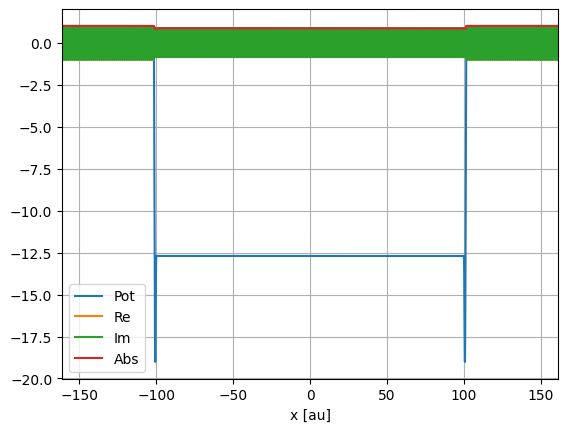

In [34]:
plt.plot(uxgrid,modelpot(0),label="Pot")
plt.plot(uxgrid,np.real(qppk["state"]["value"]),label="Re")
plt.plot(uxgrid,np.imag(qppk["state"]["value"]),label="Im")
plt.plot(uxgrid,np.abs(qppk["state"]["value"]),label="Abs")
plt.xlabel("x [au]")
plt.xlim([-0.8*modelpot.wellwidth, 0.8*modelpot.wellwidth])
plt.legend()
plt.grid()
plt.show()

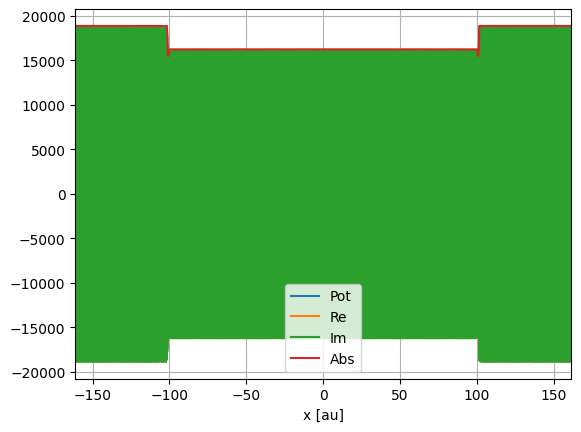

In [35]:
plt.plot(uxgrid,modelpot(0),label="Pot")
plt.plot(uxgrid,np.real(qpmk["state"]["value"]),label="Re")
plt.plot(uxgrid,np.imag(qpmk["state"]["value"]),label="Im")
plt.plot(uxgrid,np.abs(qpmk["state"]["value"]),label="Abs")
plt.xlabel("x [au]")
plt.xlim([-0.8*modelpot.wellwidth, 0.8*modelpot.wellwidth])
plt.legend()
plt.grid()
plt.show()

# Laser potential

In [36]:
t_start=0
t_stop=200.0
#t_num=10000

#utgrid=np.linspace(t_start,t_stop,t_num)
#utgrid_dt=utgrid[1]-utgrid[0]
utgrid_dt=0.05
utgrid=np.arange(t_start,t_stop,utgrid_dt)
t_num=len(utgrid)

#print(utgrid_dt)
print(t_num)

4000


In [37]:
spot_size = (800*unit_sys.ureg("nm") / unit_sys.length_unit.to("nm")).magnitude
print(spot_size)

magnitude_of_electric_field = (1.0e6*unit_sys.ureg("V/m") / unit_sys.electric_field_unit.to("V/m")).magnitude
print(magnitude_of_electric_field)

laserpot_cep0 = pots.SmoothLaserPotential(uxgrid,\
                                    spatial_min = -0.5*spot_size,\
                                    spatial_max = 0.5*spot_size,beta=0.25)

#laserpot_cep0 = LaserPotential(uxgrid)

201.5707866263765
0.02187776678796501


In [38]:
# X,Y = np.meshgrid(uxgrid,utgrid)

# Z=laserpot_cep0(Y)

# z_min, z_max = -np.abs(Z).max(), np.abs(Z).max()
    
# pcm = plt.pcolormesh(X, Y, Z, cmap ='bwr', vmin = z_min, vmax = z_max)
# plt.colorbar(pcm)
 
# plt.title('External LASER field', fontweight ="bold")
# plt.ylim(laserpot_cep0.temporal_min,1.2*laserpot_cep0.temporal_max)
# #plt.xlim(2*laserpot_cep0.spatial_min,2*laserpot_cep0.spatial_max)
# plt.xlabel("x [arb. u.]")
# plt.ylabel("time [arb. u.]")
# plt.show()

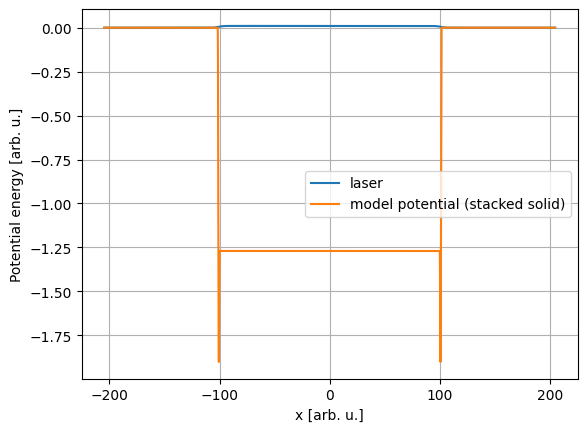

In [39]:
plt.plot(uxgrid, laserpot_cep0(laserpot_cep0.temporal_width/2),label="laser")
plt.plot(uxgrid, 0.1*modelpot(uxgrid),label="model potential (stacked solid)")
#plt.xlim([-0.8*modelpot.wellwidth, 0.8*modelpot.wellwidth])
plt.legend()
plt.xlabel("x [arb. u.]")
plt.ylabel("Potential energy [arb. u.]")
plt.grid()
plt.show()

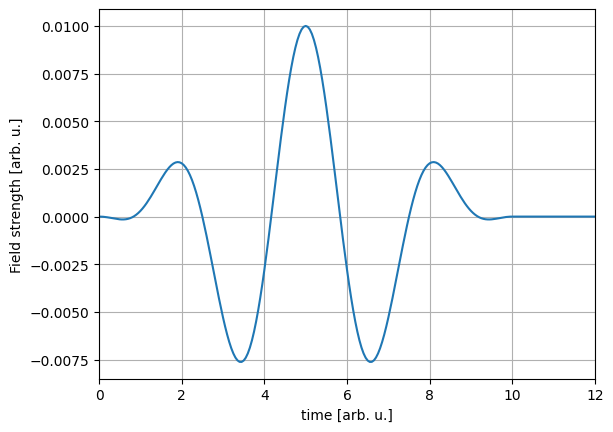

In [40]:
plt.plot(utgrid, laserpot_cep0.value_at(0.0,utgrid),label="laser")
plt.xlabel("time [arb. u.]")
plt.ylabel("Field strength [arb. u.]")
plt.xlim(0,1.2*laserpot_cep0.temporal_width)
plt.grid()
plt.show()

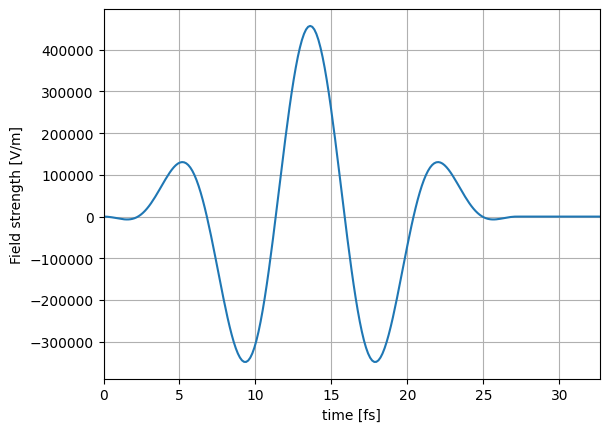

In [41]:
x = utgrid * unit_sys.time_unit.to('fs')
y = laserpot_cep0.value_at(0.0,utgrid) * unit_sys.electric_field_unit.to('V/m')

plt.plot(x, y,label="laser")
plt.xlabel("time [fs]")
plt.ylabel("Field strength [V/m]")
plt.xlim(0,1.2*laserpot_cep0.temporal_width*unit_sys.time_unit.to('fs').magnitude)
plt.grid()
plt.show()

# Vcap check

In [42]:
nx=len(uxgrid)
nt=len(utgrid)

## Advanced methode

In [43]:
import quantum_transport_toolkit as trat

ein=(1.0*unit_sys.ureg("eV") / unit_sys.energy_unit.to("eV")).magnitude #0.2
print(ein)
kin=dispersion.energy2k(ein)

qppk, qpmk = trat.quasiparticles_at_given_energy(ein,kin,ham_static)

13.229755983235565
0.019863695854161742 1.052024891678994e-06


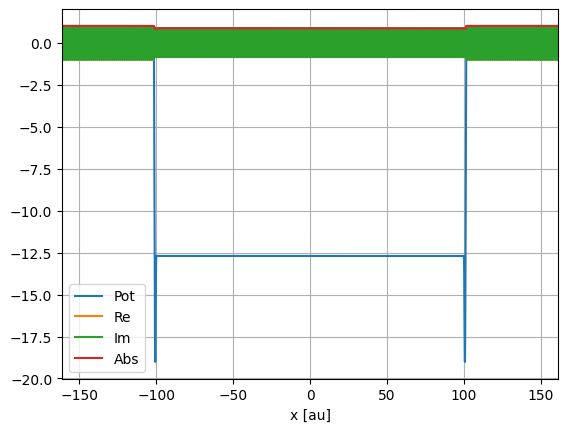

In [44]:
plt.plot(uxgrid,modelpot(0),label="Pot")
plt.plot(uxgrid,np.real(qppk["state"]["value"]),label="Re")
plt.plot(uxgrid,np.imag(qppk["state"]["value"]),label="Im")
plt.plot(uxgrid,np.abs(qppk["state"]["value"]),label="Abs")
plt.xlabel("x [au]")
plt.xlim([-0.8*modelpot.wellwidth, 0.8*modelpot.wellwidth])
plt.legend()
plt.grid()
plt.show()

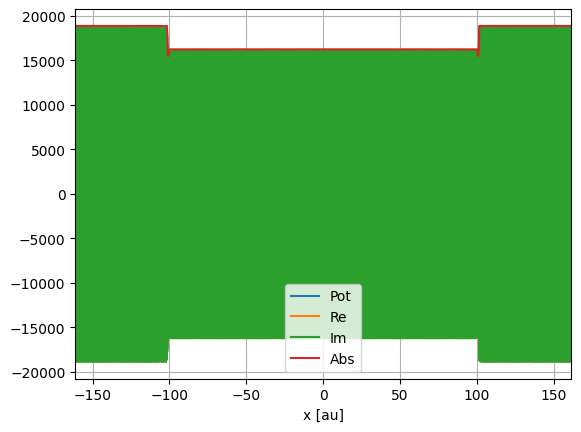

In [45]:
plt.plot(uxgrid,modelpot(0),label="Pot")
plt.plot(uxgrid,np.real(qpmk["state"]["value"]),label="Re")
plt.plot(uxgrid,np.imag(qpmk["state"]["value"]),label="Im")
plt.plot(uxgrid,np.abs(qpmk["state"]["value"]),label="Abs")
plt.xlabel("x [au]")
plt.xlim([-0.8*modelpot.wellwidth, 0.8*modelpot.wellwidth])
plt.legend()
plt.grid()
plt.show()

In [46]:
v_cap=quat.vcap_generator(uxgrid,param_x0=170,param_lambda0 = 0.2)

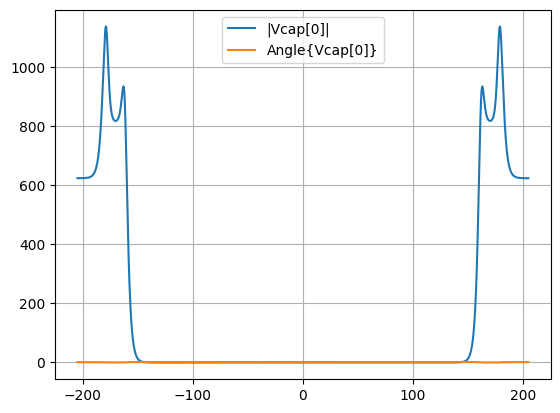

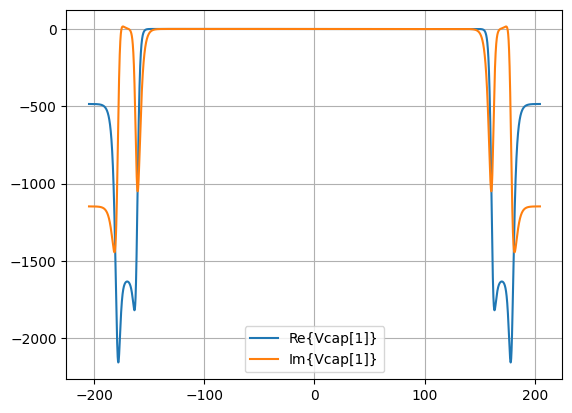

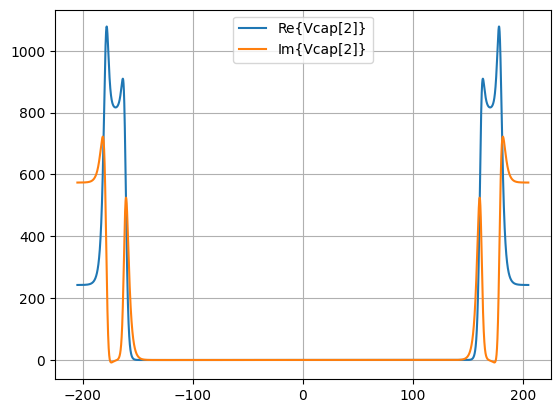

In [47]:
plt.plot(uxgrid,np.abs(v_cap[0]),label="|Vcap[0]|")
plt.plot(uxgrid,np.angle(v_cap[0]),label="Angle{Vcap[0]}")
plt.legend()
plt.grid()
plt.show()

plt.plot(uxgrid,np.real(v_cap[1]),label="Re{Vcap[1]}")
plt.plot(uxgrid,np.imag(v_cap[1]),label="Im{Vcap[1]}")
plt.legend()
plt.grid()
plt.show()

plt.plot(uxgrid,np.real(v_cap[2]),label="Re{Vcap[2]}")
plt.plot(uxgrid,np.imag(v_cap[2]),label="Im{Vcap[2]}")
plt.legend()
plt.grid()
plt.show()

In [48]:
psi_pk_te=quat.SplitTimeEvolutionCalculator(psi0_omega=qppk["energy"]/unit_sys.hb,\
        psi0_initial = qppk["state"],\
        scalarpot = modelpot,\
        vectorpot=laserpot_cep0,\
        dt=utgrid_dt, t_start=t_start, t_stop=t_stop,
        vcap=v_cap)

psi_mk_te=quat.SplitTimeEvolutionCalculator(psi0_omega=qpmk["energy"]/unit_sys.hb,\
        psi0_initial = qpmk["state"],\
        scalarpot = modelpot,\
        vectorpot=laserpot_cep0,\
        dt=utgrid_dt, t_start=t_start, t_stop=t_stop,
        vcap=v_cap)

In [49]:
psi_pk_te.run()

In [50]:
psi_mk_te.run()

/home/magashegyi/syncthing/Munka/Wigner/NEGF/code/python/git_test/quantum_toolkit.py:94: RuntimeWarning: overflow encountered in multiply
  return (np.conj(state["value"])*state["value"]).real
/usr/local/lib/python3.10/dist-packages/matplotlib/colors.py:1371: RuntimeWarning: overflow encountered in divide
  resdat /= (vmax - vmin)
/usr/local/lib/python3.10/dist-packages/matplotlib/colors.py:732: RuntimeWarning: overflow encountered in multiply
  xa *= self.N


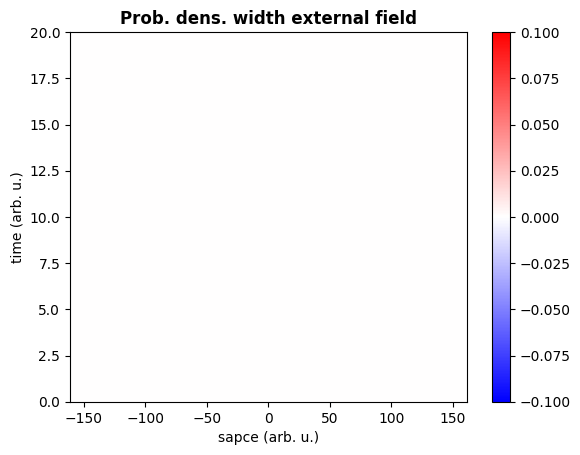

In [51]:
X,Y = np.meshgrid(uxgrid,utgrid)

Z=np.transpose(quat.probability_density(psi_pk_te.psi1_time_evolution))

z_min, z_max = -np.abs(Z).max(), np.abs(Z).max()
    
pcm = plt.pcolormesh(X,Y,Z,cmap ='bwr',vmin = z_min, vmax = z_max) #plt.pcolormesh(X, Y, Z, cmap ='bwr', vmin = z_min, vmax = z_max)
plt.colorbar(pcm)
 
plt.title('Prob. dens. width external field', fontweight ="bold")
plt.xlabel("sapce (arb. u.)")
plt.ylabel("time (arb. u.)")
plt.xlim([-0.8*modelpot.wellwidth, 0.8*modelpot.wellwidth])
plt.ylim(0,2*laserpot_cep0.temporal_width)
plt.show()

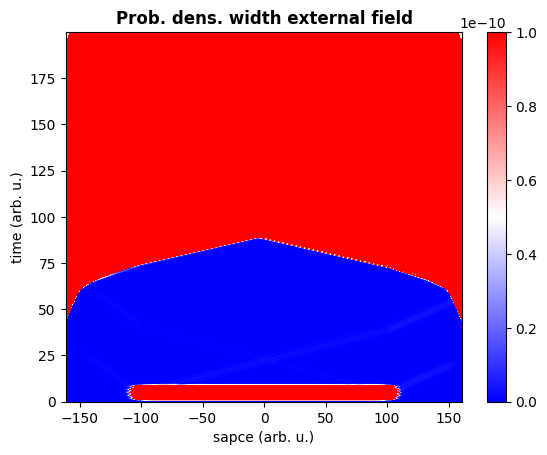

In [52]:
X,Y = np.meshgrid(uxgrid,utgrid)

Z=np.transpose(quat.probability_density(psi_pk_te.psi1_time_evolution))

#z_min, z_max = -np.abs(Z).max(), np.abs(Z).max()
    
pcm = plt.pcolormesh(X,Y,Z,cmap ='bwr',vmax=1e-10) #plt.pcolormesh(X, Y, Z, cmap ='bwr', vmin = z_min, vmax = z_max)
plt.colorbar(pcm)

plt.title('Prob. dens. width external field', fontweight ="bold")
plt.xlabel("sapce (arb. u.)")
plt.ylabel("time (arb. u.)")
plt.xlim([-0.8*modelpot.wellwidth, 0.8*modelpot.wellwidth])
#plt.ylim(2*laserpot_cep0.temporal_width,1200)
plt.show()

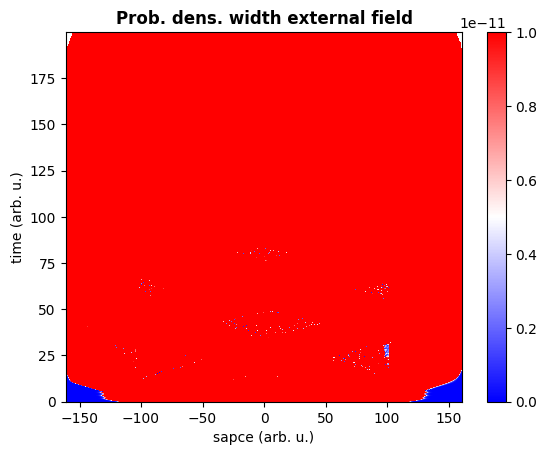

In [53]:
X,Y = np.meshgrid(uxgrid,utgrid)

Z=np.transpose(quat.probability_density(psi_mk_te.psi1_time_evolution))

#z_min, z_max = -np.abs(Z).max(), np.abs(Z).max()
    
pcm = plt.pcolormesh(X,Y,Z,cmap ='bwr',vmax=1e-11) #plt.pcolormesh(X, Y, Z, cmap ='bwr', vmin = z_min, vmax = z_max)
plt.colorbar(pcm)
 
plt.title('Prob. dens. width external field', fontweight ="bold")
plt.xlabel("sapce (arb. u.)")
plt.ylabel("time (arb. u.)")
plt.xlim([-0.8*modelpot.wellwidth, 0.8*modelpot.wellwidth])
#plt.ylim(0,1200)#2*laserpot_cep0.temporal_width)
plt.show()

# Compare with masked

In [54]:
masked_psi_pk_te=quat.SplitTimeEvolutionCalculator(psi0_omega=qppk["energy"]/quat.hartree_atomic_units.hb,\
        psi0_initial = qppk["state"],\
        scalarpot = modelpot,\
        vectorpot=laserpot_cep0,\
        dt=utgrid_dt, t_start=t_start, t_stop=t_stop,\
        vcap=v_cap, mask=mask)

masked_psi_mk_te=quat.SplitTimeEvolutionCalculator(psi0_omega=qpmk["energy"]/quat.hartree_atomic_units.hb,\
        psi0_initial = qpmk["state"],\
        scalarpot = modelpot,\
        vectorpot=laserpot_cep0,\
        dt=utgrid_dt, t_start=t_start, t_stop=t_stop,\
        vcap=v_cap, mask=mask)

In [55]:
masked_psi_pk_te.run()

In [56]:
masked_psi_mk_te.run()

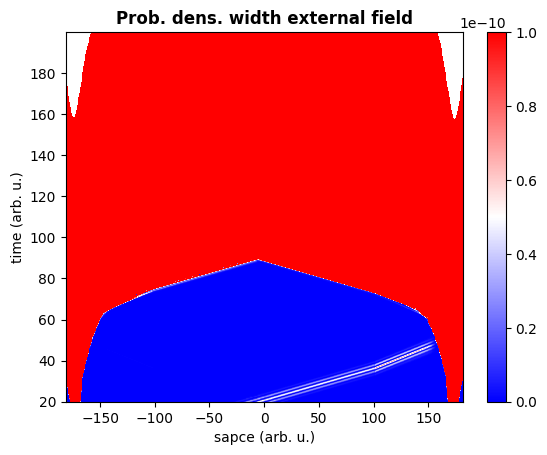

In [57]:
X,Y = np.meshgrid(uxgrid[mask],utgrid)

Z=np.transpose(quat.probability_density(masked_psi_pk_te.psi1_time_evolution))

#z_min, z_max = -np.abs(Z).max(), np.abs(Z).max()
    
pcm = plt.pcolormesh(X,Y,Z,cmap ='bwr',vmax=1e-10) #plt.pcolormesh(X, Y, Z, cmap ='bwr', vmin = z_min, vmax = z_max)
plt.colorbar(pcm)

plt.title('Prob. dens. width external field', fontweight ="bold")
plt.xlabel("sapce (arb. u.)")
plt.ylabel("time (arb. u.)")
plt.xlim([-0.9*modelpot.wellwidth, 0.9*modelpot.wellwidth])
plt.ylim(2*laserpot_cep0.temporal_width,utgrid[-1])
plt.show()

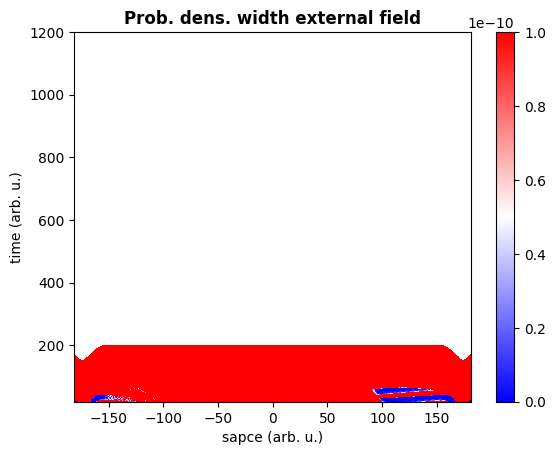

In [58]:
X,Y = np.meshgrid(uxgrid[mask],utgrid)

Z=np.transpose(quat.probability_density(masked_psi_mk_te.psi1_time_evolution))

#z_min, z_max = -np.abs(Z).max(), np.abs(Z).max()
    
pcm = plt.pcolormesh(X,Y,Z,cmap ='bwr',vmax=1e-10) #plt.pcolormesh(X, Y, Z, cmap ='bwr', vmin = z_min, vmax = z_max)
plt.colorbar(pcm)
 
plt.title('Prob. dens. width external field', fontweight ="bold")
plt.xlabel("sapce (arb. u.)")
plt.ylabel("time (arb. u.)")
plt.xlim([-0.9*modelpot.wellwidth, 0.9*modelpot.wellwidth])
plt.ylim(2*laserpot_cep0.temporal_width,1200)#2*laserpot_cep0.temporal_width)
plt.show()

# Compute probability current

In [59]:
# choose masurement points on the right and the left side
meas_point_right=105
meas_point_left=-meas_point_right

In [60]:


left_index = np.abs(np.array(uxgrid) - meas_point_left).argmin()#1300
right_index = np.abs(np.array(uxgrid) - meas_point_right).argmin()#
x_left = uxgrid[left_index]
x_right = uxgrid[right_index]

print(left_index,right_index)
print(x_left,x_right)

3992 12392
-104.99999999997732 105.00000000007043


In [61]:
pc2_pk=quat.probability_current(psi_pk_te.psi_time_evolution)
pc2_mk=quat.probability_current(psi_mk_te.psi_time_evolution)

pc2_sum=pc2_pk+pc2_mk

/home/magashegyi/syncthing/Munka/Wigner/NEGF/code/python/git_test/quantum_toolkit.py:102: RuntimeWarning: overflow encountered in multiply
  return np.imag(np.conj(state["value"]) * np.gradient(state["value"],dx,axis=0))
/tmp/ipykernel_40577/237868055.py:4: RuntimeWarning: invalid value encountered in add
  pc2_sum=pc2_pk+pc2_mk


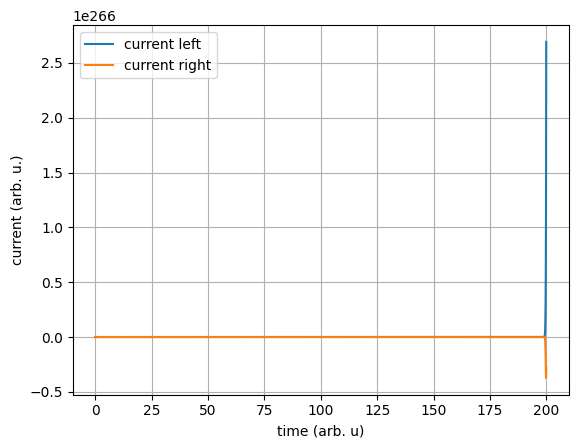

In [62]:
pc_sum_left=pc2_sum[left_index,:]
pc_sum_right=pc2_sum[right_index,:]
#pcsum_diff=pcsum_right-pcsum_left

plt.plot(utgrid, pc_sum_left,label="current left")
plt.plot(utgrid, pc_sum_right,label="current right")
#plt.plot(utgrid, pcsum_diff,label="current difference")
plt.xlabel("time (arb. u)")
plt.ylabel("current (arb. u.)")
#plt.xlim(0,40)
plt.legend()
#plt.ylim(-1e-5,1e-5)
plt.grid()
plt.show()

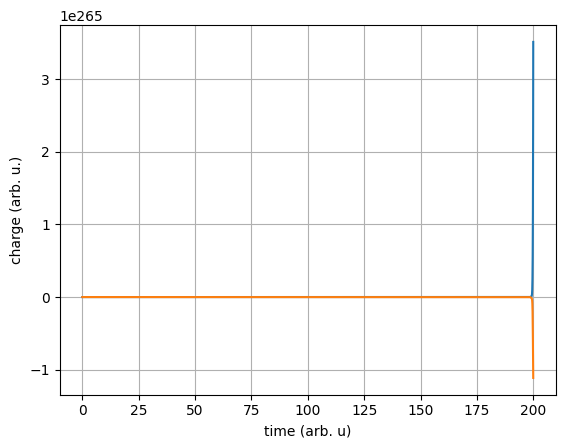

In [63]:
from scipy import integrate

charge_left = integrate.cumtrapz(pc_sum_left, utgrid, initial=0)
charge_right = integrate.cumtrapz(pc_sum_right, utgrid, initial=0)
#charge_diff = integrate.cumtrapz(pcsum_diff, utgrid, initial=0)

plt.plot(utgrid, charge_left,label="charge left")
plt.plot(utgrid, charge_right,label="charge right")
#plt.plot(utgrid, charge_left+charge_right)
#plt.plot(utgrid, charge_diff)
plt.xlabel("time (arb. u)")
plt.ylabel("charge (arb. u.)")
#plt.xlim(100)
#plt.ylim(-1e-3,1e-3)
plt.grid()
plt.show()

# compare with masked grid results

In [64]:
masked_pc2_pk=quat.probability_current(masked_psi_pk_te.psi_time_evolution)
masked_pc2_mk=quat.probability_current(masked_psi_mk_te.psi_time_evolution)

masked_pc2_sum=masked_pc2_pk+masked_pc2_mk

/tmp/ipykernel_40577/1507531803.py:4: RuntimeWarning: invalid value encountered in add
  masked_pc2_sum=masked_pc2_pk+masked_pc2_mk


In [65]:
masked_left_index = np.abs(np.array(reduced_uxgrid) - meas_point_left).argmin()#1300
masked_right_index = np.abs(np.array(reduced_uxgrid) - meas_point_right).argmin()#
masked_x_left = reduced_uxgrid[masked_left_index]
masked_x_right = reduced_uxgrid[masked_right_index]

print(masked_x_left,masked_x_right)

-105.19999999997736 104.80000000007038


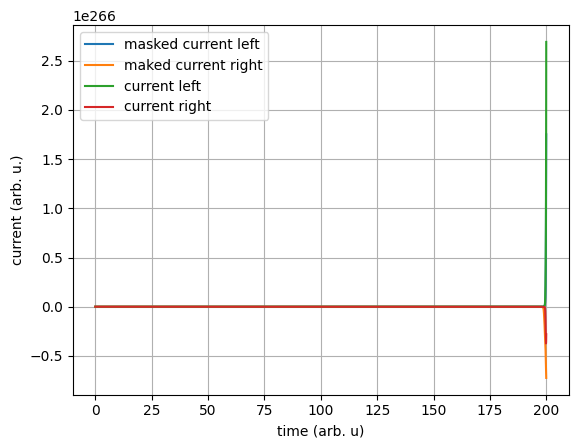

In [66]:
masked_pc_sum_left=masked_pc2_sum[masked_left_index,:]
masked_pc_sum_right=masked_pc2_sum[masked_right_index,:]
#pcsum_diff=pcsum_right-pcsum_left

plt.plot(utgrid, masked_pc_sum_left,label="masked current left")
plt.plot(utgrid, masked_pc_sum_right,label="maked current right")
plt.plot(utgrid, pc_sum_left,label="current left")
plt.plot(utgrid, pc_sum_right,label="current right")
#plt.plot(utgrid, pcsum_diff,label="current difference")
plt.xlabel("time (arb. u)")
plt.ylabel("current (arb. u.)")
#plt.xlim(0,40)
plt.legend()
#plt.ylim(-1e-5,1e-5)
plt.grid()
plt.show()

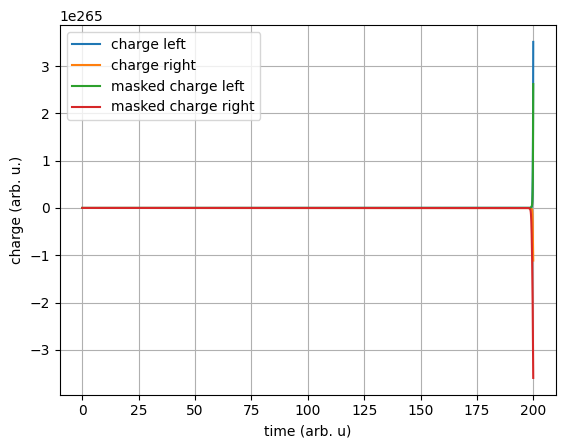

In [67]:
from scipy import integrate

masked_charge_left = integrate.cumtrapz(masked_pc_sum_left, utgrid, initial=0)
masked_charge_right = integrate.cumtrapz(masked_pc_sum_right, utgrid, initial=0)
#charge_diff = integrate.cumtrapz(pcsum_diff, utgrid, initial=0)

plt.plot(utgrid, charge_left,label="charge left")
plt.plot(utgrid, charge_right,label="charge right")
plt.plot(utgrid, masked_charge_left,label="masked charge left")
plt.plot(utgrid, masked_charge_right,label="masked charge right")
plt.xlabel("time (arb. u)")
plt.ylabel("charge (arb. u.)")
#plt.xlim(100)
#plt.ylim(-1e-3,1e-3)
plt.legend()
plt.grid()
plt.show()

In [ ]:
from atomic_units.optimizer import optimize_atomic_units

# Define parameters
dx = 0.025
emax = 5
desired_points_in_lamda = 20
desired_width = 1600

# Perform optimization
result = optimize_atomic_units(dx, emax, desired_points_in_lamda, desired_width)
print("Optimized parameters:", result['optimized_parameters'])
print("Objective function value:", result['objective_value'])